# 05d – Time-series model with PyCaret: NYC Citi Bike

**Worked on by:** Andreas Schellekens (time-series setup, model comparison, weather scenarios, 30-day evaluation, the period forecast for the API)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `03_model_baseline.ipynb` to `05c_model_ensemble.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Goal and setup

The models of 03 to 05c predict **one day**: the date and that day's weather go in, the number of trips comes out. They treat every day as a separate row, and know about the growth of the system only through the level feature `level_12m`.

The web page also needs a **period**: the expected trips for every day of the next 30 days. For that a **time-series model** is the natural tool. It learns from the *order* of the days (the trend, the weekly rhythm, how a day depends on the days before it) and forecasts a whole stretch of days at once. This notebook builds one with **PyCaret's time-series module** (`pycaret.time_series`, built on `sktime`).

The protocol of 03 (section 3) still applies: the same target `log(demand_ratio)`, the same training days, the validation year 2024 for the checks, the test period once, and the same `evaluate` helper for the metrics in trips. Two things are different for a time-series model, explained where they come up:
- **the folds** (section 5);
- **refitting at the forecast origin:** a time-series model forecasts forward from the last day it has seen. To forecast the test period, and later the API's period, it is fitted again with the *same* configuration on all days before the forecast starts (section 9).

As in 04, `lightgbm` is imported before PyCaret (a crash on Windows otherwise), and every experiment uses `n_jobs=1`. LightGBM's own log messages are sent to a quiet logger, because the many refits in this notebook would otherwise fill it with thousands of info lines.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import logging
import time
from pathlib import Path

import joblib
import lightgbm  # must be imported before pycaret
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from pycaret.time_series import TSForecastingExperiment
from sklearn.base import clone

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

# LightGBM writes an info line for every fit; the many refits below would fill the notebook with them
lightgbm_log = logging.getLogger("lightgbm")
lightgbm_log.setLevel(logging.ERROR)
lightgbm.register_logger(lightgbm_log)

NOTEBOOK = "05d_model_timeseries"
RANDOM_STATE = 42
HORIZON = 366          # PyCaret's forecast horizon: one year, the length of the validation year 2024
PERIOD_DAYS = 30       # the period the web page shows
MODEL_DIR = Path("models")
METRICS_PATH = MODEL_DIR / "metrics.csv"
FORECAST_PATH = MODEL_DIR / "citibike_timeseries_forecast.csv"
PREDICTIONS_PATH = MODEL_DIR / "citibike_timeseries_predictions.csv"
INFO_PATH = MODEL_DIR / "citibike_timeseries.json"
FORECAST_END = pd.Timestamp("2027-12-31")
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


def evaluate(name, split, actual, predicted):
    error = predicted - actual
    has_trips = actual > 0
    percentage = error[has_trips] / actual[has_trips] * 100
    return {
        "model": name, "notebook": NOTEBOOK, "split": split, "days": len(actual),
        "mae": error.abs().mean(), "rmse": np.sqrt((error ** 2).mean()),
        "mape": percentage.abs().mean(), "median_ape": percentage.abs().median(),
        "within_20pct": (percentage.abs() <= 20).mean() * 100, "bias_pct": percentage.mean(),
    }


train, validation, test = load("train"), load("validation"), load("test")
print(f"train {train.index.min():%Y-%m-%d} to {train.index.max():%Y-%m-%d} ({len(train):,} days), "
      f"validation {len(validation)} days, test {len(test)} days (to {test.index.max():%Y-%m-%d})")

train 2014-07-01 to 2023-12-31 (3,471 days), validation 366 days, test 607 days (to 2026-08-30)


## 2. The target

The target is the same as in 03 to 05c: **`log(demand_ratio)`**, the logarithm of the day's trips divided by `level_12m`, the average trips per day over the published months *m-13* to *m-2* (02 section 6). Predicted trips = exp(forecast) x `level_12m`. The growth of the system is in the level; the time-series model forecasts how a day relates to that level.

**Why not the trips themselves?** A first version of this notebook forecast `log(trips)`. Its time-series models remove a linear trend from the series, and that trend, fitted on 2014-2026, carries the strong growth of those years forward. Growth stopped in 2025-2026 (January-August 2026 has as many trips as January-August 2025), but that forecast kept climbing: October 2026 at 184,000 trips a day against 152,000 in October 2025, and 230,000 in September 2027. With the ratio, the level does that work, and it only uses published months. For months whose level window is not published yet, the forecast keeps the newest level: no growth is assumed beyond what has been measured (section 11). The deployed model of 05a and the API already work this way.

**The ten storm days without any trips** (9 in training, 1 in the test period) have no logarithm. A time-series model also needs a value for every day; it cannot skip a row like the regression models of 03 to 05c. For fitting only, these days are filled by linear interpolation between the neighbouring days on the log scale. In the evaluation they keep their 0 trips, as the protocol says.

The plot shows the trips and the level (top) and the ratio (bottom): the level carries the growth from about 20,000 to over 100,000 trips a day; the ratio keeps the yearly wave of the seasons, the COVID-19 dip of spring 2020, and the downward spikes of storms and holidays.

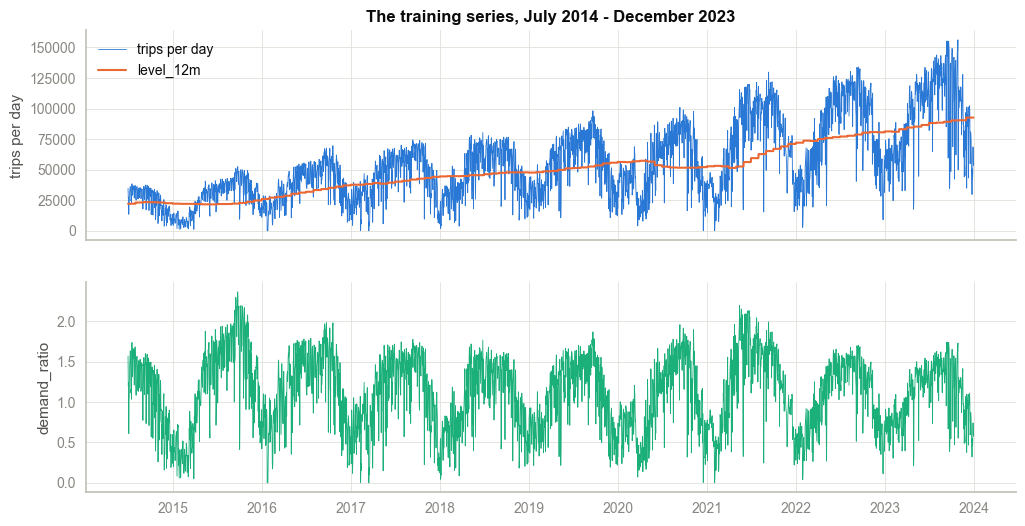

days filled for fitting: 9 in train, 0 in validation, 1 in test


In [2]:
def log_ratio(days):
    # log(trips / level_12m); storm days with 0 trips are interpolated (fitting only, never in the evaluation)
    return np.log((days["total"] / days["level_12m"]).where(days["total"] > 0)).interpolate(limit_direction="both")


fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(train.index, train["total"], color=BLUE, lw=0.6, label="trips per day")
axes[0].plot(train.index, train["level_12m"], color=ORANGE, lw=1.5, label="level_12m")
axes[0].set(ylabel="trips per day", title="The training series, July 2014 - December 2023")
axes[0].legend(loc="upper left")
axes[1].plot(train.index, train["total"] / train["level_12m"], color=AQUA, lw=0.6)
axes[1].set(ylabel="demand_ratio")
plt.show()
print("days filled for fitting:", int((train["total"] == 0).sum()), "in train,",
      int((validation["total"] == 0).sum()), "in validation,", int((test["total"] == 0).sum()), "in test")

## 3. A time-series model on the trips alone

The pure form of a time-series model sees **only the past values of the series** (here the ratio; the level then turns the forecast into trips). We try PyCaret's classic univariate models with a weekly seasonal period of 7 days:
- *naive*: tomorrow equals today;
- *seasonal naive*: equals the same weekday last week;
- *exponential smoothing*: a weighted average of the past with a trend and a weekly pattern. PyCaret's *ETS* is the same idea in another implementation; it crashes with the installed versions of `sktime` and `statsmodels`, so it is left out;
- *Theta*: a damped trend plus smoothing.

Each forecasts the whole year 2024 from the end of the training data. This shows what such a model can do without any knowledge of the weather or the calendar.

In [3]:
def as_series(values, index):
    # sktime needs a regular daily PeriodIndex
    return pd.Series(np.asarray(values), index=pd.PeriodIndex(index, freq="D"))


univariate = TSForecastingExperiment()
univariate.setup(data=as_series(log_ratio(train), train.index), fh=HORIZON, fold=3, seasonal_period=7,
                 session_id=RANDOM_STATE, n_jobs=1, verbose=False)
rows = []
for model_id in ["naive", "snaive", "exp_smooth", "theta"]:
    model = univariate.finalize_model(univariate.create_model(model_id, cross_validation=False, verbose=False))
    log_predicted = model.predict(fh=np.arange(1, len(validation) + 1)).to_numpy().ravel()
    predicted = pd.Series(np.exp(log_predicted) * validation["level_12m"].to_numpy(), index=validation.index)
    rows.append(evaluate(f"univariate {model_id}", "validation", validation["total"], predicted))
pd.DataFrame(rows).set_index("model")[["mape", "median_ape", "within_20pct", "bias_pct"]].round(1)

,mape,median_ape,within_20pct,bias_pct
model,,,,
univariate naive,50.3,56.2,9.3,-38.9
univariate snaive,53.9,57.1,9.8,-43.3
univariate exp_smooth,49.9,56.7,9.6,-38.7
univariate theta,50.6,56.6,8.7,-39.4


**Interpretation:** without weather and calendar, every univariate model fails. The 2024 error is 50-54% MAPE, with a bias of -39% to -43%. Each model forecasts the whole year from 31 December 2023, so it carries the low winter ratio of late December forward into spring and summer. The seasonal naive model literally repeats the last week of December. These models know the weekly rhythm, but not the seasons (a yearly cycle of 365 days is too long for them) and not the weather. A time-series model for this series needs the exogenous inputs of section 4.

## 4. Weather and calendar as inputs

PyCaret's time-series models can also use **exogenous variables**: extra columns that are known for every day of the forecast. We give them the information the EDA found important (01b, 01c), as numbers, because a time-series model needs numeric inputs without gaps:

| Group | Columns |
|---|---|
| Weather | `tmax_c` and its square (the temperature curve), `tmin_c`, `precipitation_mm`, `snowfall_mm`, `snow_depth_mm` |
| Calendar | `sat`, `sun` (weekend), `holiday`, `christmas_week`, the four big holidays (Thanksgiving, the day after, Christmas Day, New Year's Day) |
| Season | `doy_sin1`, `doy_cos1`, `doy_sin2`, `doy_cos2`: sine and cosine of the day of the year, one and two waves a year |

**Paths not taken:**
- *Wind:* 220 training days are missing, and exogenous columns may not have gaps. It added almost nothing in 02 and 05a.
- *`level_12m` as an input:* it is already in the target (the ratio), as in 03 to 05c.
- *Month as a category:* two sine/cosine pairs describe the yearly wave with 4 numbers instead of 11 dummy columns, without jumps at the start of a month.

**Normal weather for the period forecast.** For the 30 days on the web page the real weather is not known. Averaging the weather first and forecasting with that average does not work well: the average day has 3 to 4 mm of rain, so the model would see a "light rain" day every day, while most real days are dry and a few are very wet. So we turn it around. **Every future day is forecast once with the weather of that calendar day in each past year** (one *weather scenario* per complete year), and the forecasts are averaged. The spread of the scenarios (10th to 90th percentile) shows how much the weather alone can move a day; the web page can draw it as a band.

For display only, `typical_weather` gives the smoothed average weather of each calendar day (a 31-day window, so one wet day in the history does not become a "wet date").

In [4]:
WEATHER = ["tmax_c", "tmin_c", "precipitation_mm", "snowfall_mm", "snow_depth_mm"]
CALENDAR = ["holiday", "christmas_week", "thanksgiving", "day_after_thanksgiving", "christmas_day", "new_years_day"]
EXOGENOUS = ["tmax_c", "tmax_c_sq", "tmin_c", "precipitation_mm", "snowfall_mm", "snow_depth_mm", "sat", "sun",
             *CALENDAR, "doy_sin1", "doy_cos1", "doy_sin2", "doy_cos2"]


def exogenous(days):
    # The numeric inputs of the time-series model, for days with weekday, calendar and weather columns
    out = days[WEATHER + CALENDAR].astype(float)
    out["tmax_c_sq"] = out["tmax_c"] ** 2
    out["sat"] = (days["weekday"] == 5).astype(float)
    out["sun"] = (days["weekday"] == 6).astype(float)
    angle = 2 * np.pi * days["day_of_year"] / 365.25
    for k in (1, 2):
        out[f"doy_sin{k}"] = np.sin(k * angle)
        out[f"doy_cos{k}"] = np.cos(k * angle)
    return out[EXOGENOUS]


def scenario_years(history):
    # Complete calendar years in the history: each one is a weather scenario
    days_per_year = history.groupby(history.index.year).size()
    return [int(year) for year, n in days_per_year.items() if n >= 365]


def with_weather_of(days, history, year):
    # The days, with the measured weather of the same calendar day in an earlier year
    source = history[history.index.year == year].set_index("day_of_year")[WEATHER]
    source = source.reindex(range(1, 367)).ffill()  # day 366 in a non-leap year: use day 365
    days = days.copy()
    days[WEATHER] = source.loc[days["day_of_year"]].to_numpy()
    return days


def typical_weather(history):
    # For display: average weather per day of the year, smoothed over 31 days (also across the year's end)
    by_day = history.groupby("day_of_year")[WEATHER].mean().reindex(range(1, 367)).interpolate()
    wrapped = pd.concat([by_day.iloc[-15:], by_day, by_day.iloc[:15]])
    return wrapped.rolling(31, center=True).mean().iloc[15:-15]


print("weather scenarios from the training data:", scenario_years(train))
typical_weather(train).iloc[[0, 31, 120, 181, 211, 334]].round(1)

weather scenarios from the training data: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,tmax_c,tmin_c,precipitation_mm,snowfall_mm,snow_depth_mm
day_of_year,,,,,
1,6.2,-0.2,3.1,3.1,9.6
32,5.3,-1.8,3.5,9.4,42.1
121,18.9,9.7,3.7,0.0,0.0
182,28.6,20.3,4.3,0.0,0.0
212,29.6,21.5,4.3,0.0,0.0
335,9.6,3.2,3.8,0.8,1.5


## 5. Comparing time-series models with PyCaret

PyCaret's `setup` gets the training series with the exogenous columns:

| Setting | Value | Why |
|---|---|---|
| `fh` | 366 | every candidate forecasts one year ahead, as for the validation year |
| `fold` | 3 | expanding-window folds: fit on everything before, forecast the next 366 days |
| `seasonal_period` | 7 | the weekly rhythm (the yearly wave is in the sine/cosine columns) |

**The candidates** are the models in PyCaret's library that can use exogenous columns:
- *`*_cds_dt` models:* PyCaret removes the weekly pattern ("conditional deseasonalize") and a linear trend ("detrend") from the series. A regression model then predicts the rest from the recent days (a window of lags) plus the exogenous columns, one day after the other. We try a linear, a ridge, a Huber, a LightGBM and a gradient boosting regressor.
- *ARIMA* with the exogenous columns ("regression with ARIMA errors").

Classic univariate models like exponential smoothing cannot use exogenous columns, so PyCaret leaves them out. *Auto-ARIMA* was tried during development but did not finish within 30 minutes, so it is not in the list.

**Which score decides?** PyCaret keeps the last 366 training days (2023) apart as its own **hold-out year**, and makes its three folds from the years before: roughly 2020-2022. For every candidate we show the MAE of the log ratio on the folds, the MAE on the 2023 hold-out, and the MAPE in trips on 2023.

The choice is made on the **2023 hold-out**. In a first version of this notebook the folds decided. That picked ARIMA by a margin of 0.001, within the noise, and ARIMA then forecast 2024 badly (21% MAPE, with erratic jumps between weekdays). The folds here are the COVID-19 years, which the protocol of 03 deliberately does not score; 2023 is a normal year inside the training data, forecast with the full history before it. The validation year 2024 plays no part in the choice.

In [5]:
X_train = exogenous(train)
data = X_train.assign(log_ratio=log_ratio(train))
data.index = pd.PeriodIndex(data.index, freq="D")

experiment = TSForecastingExperiment()
experiment.setup(data=data, target="log_ratio", fh=HORIZON, fold=3, seasonal_period=7,
                 session_id=RANDOM_STATE, n_jobs=1, verbose=False)

CANDIDATES = ["lr_cds_dt", "ridge_cds_dt", "huber_cds_dt", "lightgbm_cds_dt", "gbr_cds_dt", "arima"]
holdout_days = train.iloc[-HORIZON:]  # PyCaret's hold-out: the last 366 training days (2023)
holdout_actual, holdout_level = holdout_days["total"].to_numpy(), holdout_days["level_12m"].to_numpy()
start = time.time()
ranked = experiment.compare_models(include=CANDIDATES, sort="MAE", n_select=len(CANDIDATES), verbose=False)
folds = experiment.pull()  # one row per candidate, in the same order as the returned models
models, rows = {}, {}
for model_id, model in zip(folds.index, ranked):
    models[model_id] = model
    holdout_log = experiment.predict_model(model, verbose=False)["y_pred"].to_numpy()  # forecasts the hold-out year 2023
    holdout = experiment.pull()
    rows[model_id] = {"model": folds.loc[model_id, "Model"], "folds_MAE": folds.loc[model_id, "MAE"],
                      "holdout_2023_MAE": holdout["MAE"].iloc[0],
                      "holdout_2023_MAPE_trips": np.mean(np.abs(np.exp(holdout_log) * holdout_level - holdout_actual)
                                                          / holdout_actual) * 100}
comparison = pd.DataFrame(rows).T.sort_values("holdout_2023_MAE")
model_name = comparison.index[0]  # PyCaret's id
best = models[model_name]
print(f"comparison: {time.time() - start:.0f} s; chosen on the 2023 hold-out: {model_name}")
comparison

comparison: 223 s; chosen on the 2023 hold-out: lightgbm_cds_dt


,model,folds_MAE,holdout_2023_MAE,holdout_2023_MAPE_trips
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize...,0.2314,0.122,12.078091
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Det...,0.2383,0.1382,13.654901
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.2639,0.1575,15.759276
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.2636,0.1578,15.794002
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.2804,0.176,19.252589
arima,ARIMA,0.2647,0.3076,24.976789


**Interpretation**

- **LightGBM wins:** on the 2023 hold-out it reaches an MAE of 0.122 on the log ratio, or 12.1% MAPE in trips. Gradient boosting is second (13.7%), the linear and ridge models follow (15.8%), then Huber (19.3%) and ARIMA (25.0%).
- **In this version the folds and the hold-out agree on the winner** (LightGBM is first on both). The rule of section 5 matters for ARIMA: it looks average on the folds (0.265, close to the linear models) but is clearly last on the normal year 2023.
- **The fold errors are about twice the hold-out errors** (0.23-0.28 against 0.12-0.31) because the folds forecast the COVID-19 years.
- **Trees win, as in 04 and 05a:** the effect of temperature and rain on the ratio is not linear (01b), and LightGBM finds that curve itself.

## 6. Tuning the chosen model

`tune_model` runs a random search over the hyperparameters PyCaret defines for this model (10 combinations), scored on the three folds. With `choose_better=True` PyCaret keeps the untuned model if no tuned version beats it on the folds. As in section 5, we then also compare the tuned and the untuned model on the 2023 hold-out, and keep the tuned one only if it is better there too.

In [6]:
start = time.time()
tuned = experiment.tune_model(best, n_iter=10, optimize="MAE", choose_better=True, verbose=False)
tuned_folds = experiment.pull().loc["Mean", "MAE"]
experiment.predict_model(tuned, verbose=False)
tuned_holdout = experiment.pull()["MAE"].iloc[0]
print(f"tuning: {time.time() - start:.0f} s")
print(f"untuned: folds {comparison.loc[model_name, 'folds_MAE']:.4f}, hold-out 2023 {comparison.loc[model_name, 'holdout_2023_MAE']:.4f}")
print(f"tuned:   folds {tuned_folds:.4f}, hold-out 2023 {tuned_holdout:.4f}")
chosen = tuned if tuned_holdout < comparison.loc[model_name, "holdout_2023_MAE"] else best
print("kept:", "tuned" if chosen is tuned else "untuned")
print(chosen)

tuning: 246 s
untuned: folds 0.2314, hold-out 2023 0.1220
tuned:   folds 0.2453, hold-out 2023 0.1220
kept: untuned
BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [7, 6, 5,
                                                                        4, 3, 2,
                                                                        1]},
                                                   n_jobs=1)],
                    regressor=LGBMRegressor(n_jobs=1, random_state=42), sp=7,
                    window_length=7)


## 7. The validation year 2024

The chosen configuration is fitted on all training days (`finalize_model`) and forecasts the 366 days of 2024 in one go. It is scored twice:

1. **with the measured weather** of 2024: the same information as the models of 03 to 05c, so these rows are directly comparable (`metrics.csv`, 07);
2. **with normal weather**, the average over the weather scenarios of the training years: the situation of the web page, where the weather of the coming days is unknown. The difference between 1 and 2 is the price of not knowing the weather.

In [7]:
final = experiment.finalize_model(chosen)


def forecast(model, days):
    # Trips for consecutive days directly after the model's last fitted day
    X = exogenous(days)
    X.index = pd.PeriodIndex(X.index, freq="D")
    log_predicted = model.predict(fh=np.arange(1, len(days) + 1), X=X).to_numpy().ravel()
    return pd.Series(np.exp(log_predicted) * days["level_12m"].to_numpy(), index=days.index)


def forecast_normal_weather(model, days, history):
    # Mean and 10-90% range of the forecasts over the weather scenarios of the history
    runs = pd.DataFrame({year: forecast(model, with_weather_of(days, history, year)) for year in scenario_years(history)})
    return pd.DataFrame({"predicted": runs.mean(axis=1), "low": runs.quantile(0.1, axis=1),
                         "high": runs.quantile(0.9, axis=1)})


val_measured = forecast(final, validation)
val_normal = forecast_normal_weather(final, validation, train)
results = [evaluate(f"time series {model_name} (measured weather)", "validation", validation["total"], val_measured),
           evaluate(f"time series {model_name} (normal weather)", "validation", validation["total"], val_normal["predicted"])]
inside = ((validation["total"] >= val_normal["low"]) & (validation["total"] <= val_normal["high"])).mean() * 100
print(f"share of 2024 days inside the 10-90% weather range: {inside:.0f}%")
pd.DataFrame(results).set_index("model").drop(columns="notebook").round(1)

share of 2024 days inside the 10-90% weather range: 56%


,split,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
model,,,,,,,,
time series lightgbm_cds_dt (measured weather),validation,366,10926.2,14129.5,10.8,7.8,87.7,-2.4
time series lightgbm_cds_dt (normal weather),validation,366,19518.6,23586.7,20.3,14.7,66.1,-3.2


The forecast for 2024 against the real trips. The measured-weather forecast follows the rain and the cold days. The normal-weather forecast is the smooth "expected" curve that the web page shows; its band is the 10-90% range of the weather scenarios.

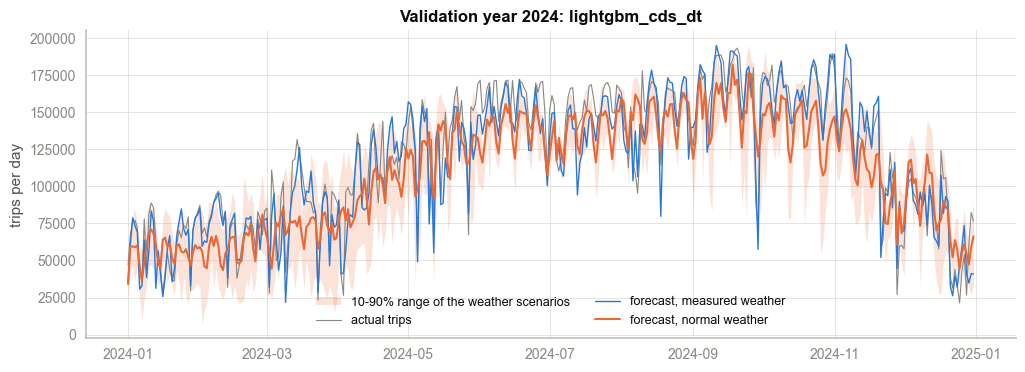

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(val_normal.index, val_normal["low"], val_normal["high"], color=ORANGE, alpha=0.18, lw=0,
                label="10-90% range of the weather scenarios")
ax.plot(validation.index, validation["total"], color=INK_MUTED, lw=0.8, label="actual trips")
ax.plot(val_measured.index, val_measured, color=BLUE, lw=1, label="forecast, measured weather")
ax.plot(val_normal.index, val_normal["predicted"], color=ORANGE, lw=1.5, label="forecast, normal weather")
ax.set(ylabel="trips per day", title=f"Validation year 2024: {model_name}")
ax.legend(loc="lower center", ncol=2, fontsize=9)
plt.show()

**Interpretation**

- **With the measured weather** the time-series model reaches a MAPE of 10.8% on 2024 (MAE 10,926 trips, 87.7% of the days within 20%, bias -2.4%). That equals the Huber model of 05b (10.8%), is better than the baseline (12.4%), and is 1.2-1.5 points behind the tree models of 04-05c (9.3-9.6%). And it forecasts the whole year from 31 December 2023, every day from 1 to 366 days ahead, in one recursive chain where each day is built on the forecasts of the days before it.
- **With normal weather** the error roughly doubles: 20.3% MAPE, 66.1% of the days within 20%, bias -3.2%. This is the price of not knowing the weather: the forecast is right on average (small bias), but a rainy or a cold day can be 30-50% below it.
- **The 10-90% band of the weather scenarios** contains 56% of the real days, not 80%. The band only shows how much the weather moves a day. The model's own error, and special days the history does not repeat, come on top. On the page the band should be called "the range of normal weather", not a prediction interval.

## 8. How good is a 30-day forecast?

The web page asks something different from section 7. It does not forecast a whole year from the end of 2023, but **the next 30 days from the last known day**, with normal weather. We simulate that on the validation year: on the first day of every month of 2024, the chosen configuration is fitted on all days before that day, then forecasts the next 30 days over the weather scenarios. That gives 12 forecasts of 30 days, 360 forecast days.

This uses the validation days only as history for the refits; nothing is chosen with it. The result is the honest error to show on the web page.

In [9]:
history_all = pd.concat([train, validation])


def refit(model, days):
    # The same configuration (hyperparameters), fitted again on the given days
    X = exogenous(days)
    X.index = pd.PeriodIndex(X.index, freq="D")
    y = log_ratio(days)
    y.index = X.index
    refitted = model.clone()
    refitted.fit(y=y, X=X, fh=np.arange(1, PERIOD_DAYS + 1))
    return refitted


start = time.time()
windows = []
for origin in pd.date_range("2024-01-01", "2024-12-01", freq="MS"):
    history = history_all[history_all.index < origin]
    days = validation.loc[origin:origin + pd.Timedelta(days=PERIOD_DAYS - 1)]
    predicted = forecast_normal_weather(refit(final, history), days, history)
    windows.append(predicted.assign(origin=origin, horizon_day=np.arange(1, len(days) + 1), actual=days["total"]))
windows = pd.concat(windows)
print(f"12 refits and forecasts: {time.time() - start:.0f} s")
has_trips = windows["actual"] > 0
windows["ape"] = (windows["predicted"] - windows["actual"]).abs() / windows["actual"] * 100
per_window = windows[has_trips].groupby("origin").agg(mape=("ape", "mean"))
per_window["period_total_error_pct"] = windows.groupby("origin").apply(
    lambda w: (w["predicted"].sum() / w["actual"].sum() - 1) * 100)
period_summary = {
    "daily_mape": windows.loc[has_trips, "ape"].mean(),
    "daily_median_ape": windows.loc[has_trips, "ape"].median(),
    "daily_within_20pct": (windows.loc[has_trips, "ape"] <= 20).mean() * 100,
    "inside_10_90_range_pct": ((windows["actual"] >= windows["low"]) & (windows["actual"] <= windows["high"])).mean() * 100,
    "period_total_mean_abs_error_pct": per_window["period_total_error_pct"].abs().mean(),
}
print({k: round(v, 1) for k, v in period_summary.items()})
per_window.round(1).T

12 refits and forecasts: 45 s
{'daily_mape': 20.6, 'daily_median_ape': 14.3, 'daily_within_20pct': 68.9, 'inside_10_90_range_pct': 56.9, 'period_total_mean_abs_error_pct': 9.1}


origin,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
mape,25.8,23.6,32.7,25.9,20.8,13.0,11.0,14.0,14.3,12.3,20.3,33.5
period_total_error_pct,-6.4,-18.7,-16.7,-2.3,-5.2,-12.9,-7.8,3.9,-7.2,-11.7,-3.1,12.8


**Interpretation:** this is the honest quality of what the web page shows.

- **Per day:** the 30-day forecasts with normal weather have a MAPE of 20.6% (median 14.3%), and 68.9% of the days are within 20%.
- **Per month:** the errors are largest in winter and early spring (December 33.5%, January to April 23.6-32.7%), when snow and cold vary most between years. They are smallest in summer and early autumn (July to October 11.0-14.3%).
- **Per period:** the total trips over 30 days are much more reliable, with a mean absolute error of 9.1% (from -18.7% for February to +12.8% for December). Rainy and dry days partly cancel out over a month.
- **On the page:** show the daily values as an expectation (typically within about 20%), and the 30-day total as the most reliable number (about +-10%).

## 9. The test period

The test period (January 2025 to 30 August 2026) is used once, after all choices. As explained in section 1, the configuration chosen on the training data is **fitted again on all days up to 31 December 2024**, with the same hyperparameters, and then forecasts the 607 test days in one go. This is what the API's forecast does from the last published day. As in section 7, it is scored with the measured weather (comparable with 03 to 05c) and with normal weather.

In [10]:
model_2024 = refit(final, history_all)
test_measured = forecast(model_2024, test)
test_normal = forecast_normal_weather(model_2024, test, history_all)
results += [evaluate(f"time series {model_name} (measured weather)", "test", test["total"], test_measured),
            evaluate(f"time series {model_name} (normal weather)", "test", test["total"], test_normal["predicted"])]
pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(1)

,,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
model,split,,,,,,,
time series lightgbm_cds_dt (measured weather),validation,366,10926.2,14129.5,10.8,7.8,87.7,-2.4
time series lightgbm_cds_dt (normal weather),validation,366,19518.6,23586.7,20.3,14.7,66.1,-3.2
time series lightgbm_cds_dt (measured weather),test,607,15305.6,19147.2,15.7,11.4,77.4,12.4
time series lightgbm_cds_dt (normal weather),test,607,21267.3,28870.3,33.4,12.0,67.0,26.5


**Interpretation**

- **With the measured weather** the test MAPE is 15.7% (MAE 15,306, 77.4% of the days within 20%), in the range of the other models (14.4-17.4%). The bias is +12.4%, higher than theirs (+7.8% to +9.4%). This is the same drift problem as in 03-05c (growth stopped in 2025-2026 while the ratio learned in growth years stays above 1), a little stronger here because the time-series model also carries the recent ratio forward.
- **With normal weather** the MAPE is 33.4% (median 12.0%, bias +26.5%). The mean is driven by January and February 2026, with daily errors of 169% and 125%: the blizzards of late January and 23-24 February, when the city was under snow, against a forecast with normal winter weather. Without those two months the MAPE is 21.2%, the level of section 8.
- **For the API:** a forecast with normal weather cannot see a blizzard coming; the page has to say that it shows the expected demand under normal weather.

## 10. Would the day models do the same?

The models of 03 to 05c can also produce a 30-day forecast with normal weather: predict every day of the period once with the weather of each past year on that date, and average, exactly as `forecast_normal_weather` does here. If the deployed model (05a) does that just as well, the time-series model would not be needed for the period forecast. This section checks that on **the same 30-day windows as section 8** (the first of every month of 2024), and reports the same windows in the test period (the first of every month from January 2025 to August 2026). The test windows are reported only, as in section 9; the choice is made on 2024.

Candidates, all with the weather scenarios of the complete years before the window's first day:
- **05d time series:** the configuration of this notebook, refitted at every first day (as in section 8);
- **05a deployed:** the saved gradient boosting model exactly as the API serves it (fitted on the training days up to 2023);
- **05a retrained at the origin:** the same hyperparameters, fitted on all days with trips before the window's first day, the fair counterpart of the refit of the time-series model;
- **05c ensemble:** the saved ensemble, for reference.

The day models also get the wind of the scenario year (missing values allowed), and the ensemble the precipitation class and snow flag derived from it as in 02.

In [11]:
gradient_boosting = joblib.load(MODEL_DIR / "citibike_gradient_boosting.joblib")
ensemble = joblib.load(MODEL_DIR / "citibike_ensemble.joblib")
gradient_boosting_columns = json.loads((MODEL_DIR / "citibike_gradient_boosting.json").read_text())["input_columns"]
ensemble_columns = json.loads((MODEL_DIR / "citibike_ensemble.json").read_text())["input_columns"]
DAY_MODEL_WEATHER = WEATHER + ["wind_ms"]


def day_model_normal_weather(model, columns, days, history):
    # Mean forecast in trips of a day model over the weather scenarios of the history
    runs = []
    for year in scenario_years(history):
        source = history[history.index.year == year].set_index("day_of_year")[DAY_MODEL_WEATHER]
        scenario = days.copy()
        scenario[DAY_MODEL_WEATHER] = source.reindex(range(1, 367)).ffill().loc[days["day_of_year"]].to_numpy()
        mm = scenario["precipitation_mm"]  # the precipitation class and snow flag of 02, for the ensemble
        scenario["precipitation"] = np.select([mm == 0, mm <= 2.5, mm <= 10, mm <= 25],
                                              ["dry", "light", "moderate", "heavy"], "very heavy")
        scenario["snow_on_ground"] = (scenario["snow_depth_mm"] > 0).astype(int)
        runs.append(np.exp(model.predict(scenario[columns])) * days["level_12m"].to_numpy())
    return pd.Series(np.mean(runs, axis=0), index=days.index)


def period_windows(target, origins, known_days):
    # 30-day forecasts with normal weather from every origin, for the four candidates
    rows = []
    for origin in origins:
        history = known_days[known_days.index < origin]
        days = target.loc[origin:origin + pd.Timedelta(days=PERIOD_DAYS - 1)]
        fit_days = history[history["total"] > 0]
        retrained = clone(gradient_boosting).fit(fit_days[gradient_boosting_columns], log_ratio(fit_days))
        candidates = {
            "05d time series": forecast_normal_weather(refit(final, history), days, history)["predicted"],
            "05a deployed": day_model_normal_weather(gradient_boosting, gradient_boosting_columns, days, history),
            "05a retrained at the origin": day_model_normal_weather(retrained, gradient_boosting_columns, days, history),
            "05c ensemble": day_model_normal_weather(ensemble, ensemble_columns, days, history),
        }
        for name, predicted in candidates.items():
            rows.append(pd.DataFrame({"model": name, "origin": origin, "predicted": predicted, "actual": days["total"]}))
    return pd.concat(rows)


def period_scores(w):
    has_trips = w["actual"] > 0
    ape = ((w["predicted"] - w["actual"]).abs() / w["actual"] * 100)[has_trips]
    totals = w.groupby("origin").apply(lambda g: (g["predicted"].sum() / g["actual"].sum() - 1) * 100)
    return pd.Series({"daily_mape": ape.mean(), "daily_median_ape": ape.median(), "within_20pct": (ape <= 20).mean() * 100,
                      "total_abs_error_pct": totals.abs().mean(), "total_bias_pct": totals.mean()})


start = time.time()
comparison = pd.concat([
    period_windows(validation, pd.date_range("2024-01-01", "2024-12-01", freq="MS"), history_all).assign(period="validation 2024"),
    period_windows(test, pd.date_range("2025-01-01", "2026-08-01", freq="MS"),
                   pd.concat([train, validation, test])).assign(period="test 2025-2026"),
])
print(f"32 windows x 4 models: {time.time() - start:.0f} s")
period_table = comparison.groupby(["period", "model"], sort=False).apply(period_scores)
assert abs(period_table.loc[("validation 2024", "05d time series"), "daily_mape"] - period_summary["daily_mape"]) < 1e-9
period_table.round(1)

32 windows x 4 models: 154 s


daily_mape  daily_median_ape  within_20pct  total_abs_error_pct  total_bias_pct
period          model                                                                                                       
validation 2024 05d time series                    20.6              14.3          68.9                  9.1            -6.3
                05a deployed                       19.2              14.0          70.8                  8.9            -6.6
                05a retrained at the origin        19.3              14.2          71.1                  9.0            -6.7
                05c ensemble                       19.5              13.8          69.7                  9.0            -6.9
test 2025-2026  05d time series                    30.6              11.5          68.3                 10.6             8.1
                05a deployed                       32.3              12.3          68.3                 13.0            10.8
                05a retrained at the origin        32.2              12.8          68.3                 13.0            10.9
                05c ensemble                       32.4              13.2          66.8                 12.4            10.5

The error of the 30-day total per window (in %, positive = too many trips forecast), and in how many windows the time-series model's total is closer to the actual total than the deployed model's.

In [12]:
total_error = (comparison.groupby(["period", "origin", "model"], sort=False)
               .apply(lambda g: (g["predicted"].sum() / g["actual"].sum() - 1) * 100).unstack("model"))
closer = (total_error["05d time series"].abs() < total_error["05a deployed"].abs()).groupby(level="period", sort=False)
print("windows where the time-series total is closer than the deployed model's:",
      {period: f"{won} of {n}" for period, won, n in zip(closer.sum().index, closer.sum(), closer.size())})
total_error.round(1)

windows where the time-series total is closer than the deployed model's: {'validation 2024': '3 of 12', 'test 2025-2026': '14 of 20'}


model                       05d time series  05a deployed  05a retrained at the origin  05c ensemble
period          origin                                                                              
validation 2024 2024-01-01             -6.4          -7.1                         -7.1          -7.7
                2024-02-01            -18.7         -18.6                        -18.4         -19.2
                2024-03-01            -16.7         -16.1                        -16.2         -15.7
                2024-04-01             -2.3          -9.2                         -9.6          -9.0
                2024-05-01             -5.2          -4.3                         -4.4          -5.8
                2024-06-01            -12.9          -9.7                         -9.7         -10.4
                2024-07-01             -7.8          -6.2                         -6.4          -5.3
                2024-08-01              3.9           3.7                          3.8           3.9
                2024-09-01             -7.2          -3.1                         -3.2          -3.0
                2024-10-01            -11.7          -9.8                         -9.8         -10.4
                2024-11-01             -3.1          -8.9                         -8.9          -9.0
                2024-12-01             12.8           9.9                         10.0           8.7
test 2025-2026  2025-01-01              8.6           4.7                          5.2           3.8
                2025-02-01              5.0           3.8                          4.5           3.3
                2025-03-01             -9.8         -12.0                        -10.9         -11.6
                2025-04-01              4.8          -2.8                         -2.6          -2.1
                2025-05-01             12.6          12.7                         12.8          11.1
                2025-06-01              8.3          13.3                         14.2          12.8
                2025-07-01              4.9           8.5                          8.9           9.4
                2025-08-01              5.7           9.4                          9.4           9.4
                2025-09-01              0.9           7.8                          7.5           7.9
                2025-10-01             10.5          14.4                         14.1          13.8
                2025-11-01             13.0          14.6                         13.8          13.2
                2025-12-01             25.1          29.4                         29.6          27.9
                2026-01-01             20.7          25.1                         25.4          23.6
                2026-02-01             65.7          76.5                         76.7          75.2
                2026-03-01             -3.0           0.8                          2.1           1.3
                2026-04-01             -0.8          -5.1                         -5.2          -4.5
                2026-05-01             -4.0           2.1                          1.5           0.4
                2026-06-01             -6.7          -1.5                         -1.7          -1.6
                2026-07-01              1.7           8.4                          7.7           9.4
                2026-08-01             -0.5           6.8                          5.8           6.7

**Interpretation**

- **On 2024 the two are equal.** The deployed model is a little better per day (MAPE 19.2% against 20.6%, within 20% on 70.8% against 68.9% of the days), and the 30-day totals are equally good (mean absolute error 8.9% against 9.1%). Its total is closer in 9 of the 12 windows, but the differences per window are mostly 1 to 4 points. With 12 windows, differences of 0.2 to 1.4 points are not meaningful.
- **In the test period the time-series model is better on the totals**: 10.6% against 13.0%, bias +8.1% against +10.8%, closer in 14 of the 20 windows; per day 30.6% against 32.3%. The gain comes from June 2025 to February 2026, when growth stopped and every model forecast too many trips (03 to 07). The time-series model builds on the last few days before the window, so it partly follows the lower demand; the day models only see it through `level_12m`, two months late. This is a test result: it supports the choice, it does not make it.
- **Retraining the deployed model at every origin changes nothing** (19.3% and 32.2% per day): the level feature already carries the recent growth, and nine or ten years of training data barely move with one more month.
- **February 2026 dominates the test numbers of all models** (totals +66% to +77%): blizzards that no normal-weather forecast can see.
- **Decision:** the period forecast stays with the time-series model. It is as good as the deployed model on 2024, the newest period is in its favour, and it is the PyCaret time-series model the period question asks for. The argument for the day model is consistency: the single-day view and the period view of the page would then always come from the same model. That would be the team's choice; it would need a period endpoint that computes the scenarios with 05a instead of reading the stored forecast.

## 11. The period forecast for the API

The deployed forecast is made the same way as the test forecast, from the newest data:

1. **Fit** the chosen configuration on **all days**, from July 2014 to 30 August 2026 (the last published day).
2. **Forecast** every day from 31 August 2026 to 31 December 2027 over the weather scenarios of all complete years, with the real calendar (weekends, holidays). The level of a future month is computed from `citibike_monthly.csv` exactly like in 02 (months *m-13* to *m-2*). That works for September and October 2026; from November 2026 the needed months are not published yet, so the newest level is kept. The calendar columns come from the same rules as in 02 (section 5); the cell checks that the rules give exactly the columns of 02 on all 4,444 known days.
3. **Save** it as a small CSV file, `models/citibike_timeseries_forecast.csv`. The API reads this file and returns any 30 days in that range. It does not need PyCaret or `sktime`, so it stays small enough for the free host.

The further a day lies from 30 August 2026, the less certain its forecast: the 30-day error of section 8 holds for the first month; after that the error grows.

In [13]:
def calendar_columns(index):
    # The calendar columns of 02 (section 5), built from the dates alone
    out = pd.DataFrame(index=index)
    out["weekday"] = index.weekday
    out["day_of_year"] = index.dayofyear
    out["holiday"] = index.isin(USFederalHolidayCalendar().holidays(index.min(), index.max())).astype(int)
    late_december = ((index.month == 12) & (index.day >= 24)) | ((index.month == 1) & (index.day == 1))
    out["christmas_week"] = (late_december & (out["holiday"] == 0)).astype(int)  # 24 Dec - 1 Jan, except holidays
    out["thanksgiving"] = ((index.month == 11) & (index.weekday == 3) & (index.day >= 22) & (index.day <= 28)).astype(int)
    out["day_after_thanksgiving"] = ((index.month == 11) & (index.weekday == 4) & (index.day >= 23) & (index.day <= 29)).astype(int)
    out["christmas_day"] = ((index.month == 12) & (index.day == 25)).astype(int)
    out["new_years_day"] = ((index.month == 1) & (index.day == 1)).astype(int)
    return out


all_days = pd.concat([train, validation, test])
rebuilt = calendar_columns(all_days.index)
for column in rebuilt.columns:  # the rules must give exactly the columns of 02 on every known day
    assert (rebuilt[column].to_numpy() == all_days[column].to_numpy()).all(), f"{column} differs from 02"

future = calendar_columns(pd.date_range(all_days.index.max() + pd.Timedelta(days=1), FORECAST_END, freq="D", name="date"))
future[WEATHER] = typical_weather(all_days).loc[future["day_of_year"]].to_numpy()  # shown on the page, not used by the model

monthly = pd.read_csv(DATASET["files"]["monthly"], index_col="month")
monthly.index = pd.PeriodIndex(monthly.index, freq="M")
levels, last_level = {}, None
for month in future.index.to_period("M").unique():
    window = [month - k for k in range(2, 14)]  # months m-13 .. m-2, as in 02
    published = all(m in monthly.index for m in window)
    if published:
        last_level = monthly.loc[window, "total"].sum() / monthly.loc[window, "days"].sum()
    levels[month] = (last_level, "published months" if published else "newest level kept")
future["level_12m"] = [levels[m][0] for m in future.index.to_period("M")]
future["level_source"] = [levels[m][1] for m in future.index.to_period("M")]
assert abs(levels[pd.Period("2026-08", "M")][0] - test["level_12m"].iloc[-1]) < 0.01, "level rule differs from 02"
deployed = refit(final, all_days)
period_forecast = forecast_normal_weather(deployed, future, all_days)
future["predicted_trips"] = period_forecast["predicted"].round().astype(int)
future["low_trips"] = period_forecast["low"].round().astype(int)
future["high_trips"] = period_forecast["high"].round().astype(int)
print("weather scenarios:", scenario_years(all_days))
future[["weekday", "holiday", "predicted_trips", "low_trips", "high_trips", "tmax_c", "precipitation_mm"]].head(10).round(1)

weather scenarios: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,weekday,holiday,predicted_trips,low_trips,high_trips,tmax_c,precipitation_mm
date,,,,,,,
2026-08-31,0,0,166533,161010,172450,27.5,3.9
2026-09-01,1,0,173959,174114,186114,27.3,3.9
2026-09-02,2,0,173303,140984,191832,27.2,3.7
2026-09-03,3,0,172162,156554,185816,27.1,3.7
2026-09-04,4,0,178313,158649,189593,27.0,3.5
2026-09-05,5,0,171077,159834,178163,26.8,3.3
2026-09-06,6,0,135023,91928,161681,26.7,2.9
2026-09-07,0,1,150532,143597,162538,26.6,2.6
2026-09-08,1,0,179401,169174,189045,26.6,2.7


The forecast together with the last two years of real trips.

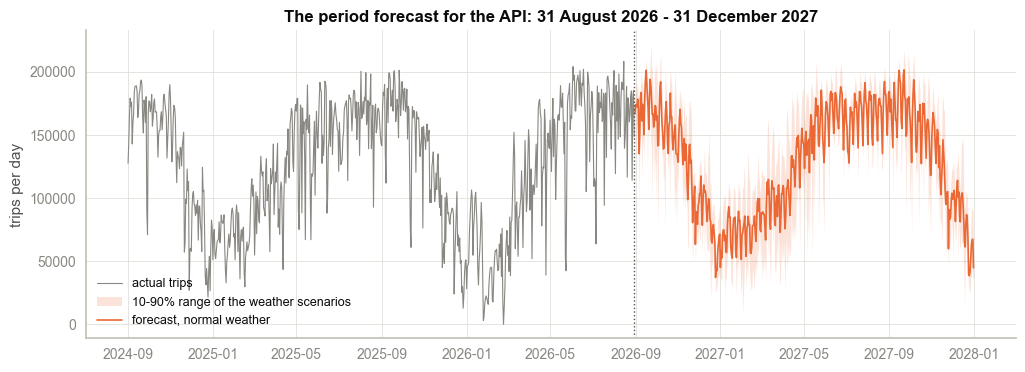

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
recent = all_days[all_days.index >= "2024-09-01"]
ax.plot(recent.index, recent["total"], color=INK_MUTED, lw=0.8, label="actual trips")
ax.fill_between(future.index, future["low_trips"], future["high_trips"], color=ORANGE, alpha=0.18, lw=0,
                label="10-90% range of the weather scenarios")
ax.plot(future.index, future["predicted_trips"], color=ORANGE, lw=1.2, label="forecast, normal weather")
ax.axvline(all_days.index.max(), color=INK_SECONDARY, ls=":", lw=1)
ax.set(ylabel="trips per day", title="The period forecast for the API: 31 August 2026 - 31 December 2027")
ax.legend(loc="lower left", fontsize=9)
plt.show()

**Interpretation**

- **The first month looks right.** The forecast for September 2026 averages 172,400 trips a day against 175,486 in September 2025, and October 156,000 against 152,049. From November 2026 the level window is not published yet, so the level stays at 124,500 trips a day. 2027 is therefore forecast at the 2026 level, with the seasonal wave on top (about 70,000 a day in January, 164,000-174,000 in summer), and no growth assumed.
- **Weekly rhythm and holidays are in the forecast:** Sundays are lower, and Labor Day (7 September 2026) is forecast at about 150,000 against about 180,000 on the Tuesday after.
- **The expected value can fall below the 10% line.** On 1 September 2026 it does, because one of the scenarios is 1 September 2021, the day of storm Ida (181 mm of rain). That single year pulls the average down. The band and the line are two different summaries of the same 11 scenarios.

## 12. Saving

| File (`models/`) | Content | Used by |
|---|---|---|
| `citibike_timeseries_forecast.csv` | One row per day from 31 August 2026 to 31 December 2027: `date`, `predicted_trips`, `low_trips` and `high_trips` (10-90% range of the weather scenarios), the `level_12m` used and where it came from, the calendar flags, and the typical weather of that date (for display) | the API |
| `citibike_timeseries.json` | Model, settings, data range, the 30-day error of section 8, the validation and test scores | the API (metadata) and the report |
| `citibike_timeseries_predictions.csv` | The validation and test forecasts per day (measured and normal weather) | `07_model_comparison.ipynb` |
| `metrics.csv` | The four rows of this notebook (validation and test, measured and normal weather) | 07 |

The fitted PyCaret model itself is not saved: the API does not need it, and this notebook re-creates it in about 15 minutes.

In [15]:
columns = ["predicted_trips", "low_trips", "high_trips", "level_12m", "level_source", "weekday", "holiday", "christmas_week", "thanksgiving",
           "day_after_thanksgiving", "christmas_day", "new_years_day"] + WEATHER
future[columns].round(1).to_csv(FORECAST_PATH, index_label="date", date_format="%Y-%m-%d")

pd.concat([pd.DataFrame({"split": "validation", "measured_weather": val_measured, "normal_weather": val_normal["predicted"]}),
           pd.DataFrame({"split": "test", "measured_weather": test_measured, "normal_weather": test_normal["predicted"]})]
          ).round(1).to_csv(PREDICTIONS_PATH, index_label="date", date_format="%Y-%m-%d")

model_info = {
    "model": f"time series {model_name} (PyCaret)",
    "notebook": NOTEBOOK,
    "estimator": str(chosen),
    "target": "log(demand_ratio) = log(trips / level_12m); storm days with 0 trips interpolated for fitting",
    "level_assumption": "level_12m from the published months m-13..m-2; when they are not published yet, the newest level is kept (no further growth assumed)",
    "exogenous_columns": EXOGENOUS,
    "weather_assumption": "normal weather: the mean of the forecasts over the weather of the same calendar day in every complete past year; low/high = 10th/90th percentile",
    "weather_scenario_years": scenario_years(all_days),
    "fitted_on": f"{all_days.index.min():%Y-%m-%d} to {all_days.index.max():%Y-%m-%d}",
    "forecast_first_day": f"{future.index.min():%Y-%m-%d}",
    "forecast_last_day": f"{future.index.max():%Y-%m-%d}",
    "period_days": PERIOD_DAYS,
    "period_error_validation_2024": {k: round(float(v), 2) for k, v in period_summary.items()},
    "validation": {r["model"]: {"mape": round(r["mape"], 2), "mae": round(r["mae"])} for r in results if r["split"] == "validation"},
    "test": {r["model"]: {"mape": round(r["mape"], 2), "mae": round(r["mae"])} for r in results if r["split"] == "test"},
}
INFO_PATH.write_text(json.dumps(model_info, indent=2))

metrics = pd.read_csv(METRICS_PATH, float_precision="round_trip")  # keeps the other rows byte-identical
metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], pd.DataFrame(results)], ignore_index=True)
metrics.to_csv(METRICS_PATH, index=False)
for path in [FORECAST_PATH, INFO_PATH, PREDICTIONS_PATH]:
    print(f"{path}  ({path.stat().st_size / 1e3:.0f} KB)")
metrics.set_index(["model", "split"])[["mae", "mape", "within_20pct", "bias_pct"]].round(1)

models\citibike_timeseries_forecast.csv  (46 KB)
models\citibike_timeseries.json  (2 KB)
models\citibike_timeseries_predictions.csv  (36 KB)


mae  mape  within_20pct  bias_pct
model                                          split                                            
seasonal naive                                 validation  17755.7  22.2          71.9       5.2
linear regression (baseline)                   validation  12787.6  12.4          82.2      -4.2
seasonal naive                                 test        24128.1  38.0          61.9      31.6
linear regression (baseline)                   test        17205.6  17.4          73.6       7.8
PyCaret blend gbr + rf + lightgbm              validation   9657.7   9.5          88.5      -3.1
                                               test        13806.2  14.6          80.9       8.6
gradient boosting (05a)                        validation   9499.5   9.6          86.1      -3.1
                                               test        14577.8  15.1          80.0       8.8
Huber regression (05b)                         validation  11645.3  10.8          88.3      -2.7
                                               test        15837.4  15.7          77.9       9.4
ensemble 05a + 05b (05c)                       validation   9712.1   9.3          90.2      -3.1
                                               test        14363.4  14.4          81.4       8.8
time series lightgbm_cds_dt (measured weather) validation  10926.2  10.8          87.7      -2.4
time series lightgbm_cds_dt (normal weather)   validation  19518.6  20.3          66.1      -3.2
time series lightgbm_cds_dt (measured weather) test        15305.6  15.7          77.4      12.4
time series lightgbm_cds_dt (normal weather)   test        21267.3  33.4          67.0      26.5

## 13. Conclusion

- **Model:** a PyCaret time-series model, `lightgbm_cds_dt`. PyCaret removes the weekly pattern and a linear trend from `log(demand_ratio)`, and LightGBM forecasts the rest from the last 7 days plus the weather and calendar inputs, one day after the other. It was chosen out of six candidates on PyCaret's 2023 hold-out (12.1% MAPE in trips). Tuning did not help, so the untuned model is kept.
- **Quality:**
  - *Validation 2024, measured weather:* 10.8% MAPE, the level of the Huber model and 1.2-1.5 points behind the tree models of 04-05c, while forecasting the whole year in one go.
  - *Test period, measured weather:* 15.7% MAPE, with a bias of +12.4%.
- **What it adds:** the **period forecast** for the web page. The next 30 days, with normal weather (the average over the weather of every past year on the same date) and a 10-90% band. Over 30 days a day is typically within about 20% (MAPE 20.6% on 2024), and the 30-day total within about 9%.
- **Against the day models (section 10):** the deployed gradient boosting model, used the same way with normal weather, is equally good on the 30-day windows of 2024 (daily MAPE 19.2% against 20.6%, 30-day total 8.9% against 9.1%); in the test period the time-series model is better on the totals (10.6% against 13.0%). The period forecast therefore stays with the time-series model.
- **Lessons:**
  - a time-series model without weather is useless here (50% MAPE);
  - the target has to be the ratio to the level, because a trend fitted on the raw trips carries the old growth into the future;
  - PyCaret's folds for this series are the COVID-19 years, so the choice was made on the 2023 hold-out;
  - a normal-weather forecast cannot see snowstorms (January-February 2026).
- **For the API:** the forecast is saved per day in `models/citibike_timeseries_forecast.csv` (31 August 2026 - 31 December 2027) with its metadata in `models/citibike_timeseries.json`. The API reads the file and needs no PyCaret. To refresh it with newer data, re-run this notebook after 02 (about 15 minutes) and commit the two files.